In [ ]:
#for the 3D cube
import jax 
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
import numpy as np
import atmo3 as a3 
pi = np.pi

# --- Example Usage ---
L0 = 1000.0   # Injection scale m
dz = 30.0     #  meter resolution
Lbox = 7500.0 # size of the box in m
fraction = 0.08 # Threshold of the maximum perturbation

N_grid = int(Lbox/dz)

cc_ratio = np.full(N_grid, fraction)


UTC_hour = 15
altitude_ground = 5100
beta = -11/3
seed = 123456789

In [3]:
from matplotlib import pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [3]:
print(N_grid , Lbox/dz)

250 250.0


In [4]:
# Initialize atmosphere
atmo = a3.Atmosphere(nside_grid=N_grid, box_length_in_m=Lbox, site_altitude=altitude_ground)

# Define wavenumbers and power spectrum
dk = atmo.grid_wsp.dk
k = np.arange(N_grid) * dk
k0 = 2 * np.pi / L0
k_tot = np.sqrt(k0**2 + k**2)
pofk = k_tot**beta
pofk/= np.max(pofk)
pspec = {'k': k, 'pofk': pofk}



delta_q_profile = np.load('/pscratch/sd/v/valer/atmo3/examples/delta_q_profiles_2023_07.npz')['delta_q_map'] #  kg/kg

mean_q_profile = np.load('/pscratch/sd/v/valer/atmo3/examples/mean_q_profiles_2023_07.npz')['typical_profiles'] #  kg/kg

altitude = np.load('/pscratch/sd/v/valer/atmo3/examples/delta_q_profiles_2023_07.npz')['alt_grid']

rescale = {'h': altitude, 'f': delta_q_profile[UTC_hour]}

mean_q = mean_q_profile[UTC_hour]
delta_q = delta_q_profile[UTC_hour]


# Add component to atmosphere
field_name_v = 'specific humidity q variations'
field_unit_v = 'kg/kg'

atmo.add_component(
    field_name=field_name_v,
    field_unit=field_unit_v,
    pspec=pspec,
    rescale=rescale,
    seed=seed,
    #mean=mean_q
)


atmo.generate_realization(time_step=0, component_name=field_name_v)

# Extract your final 3D JAX arrays
q_variations_cube = atmo.components[field_name_v].field


In [5]:
print(altitude)

[ 5102  5104  5106 ... 14996 14998 15000]


In [6]:
import pycraf.atm
import astropy.units as u

altitudes_km = altitude * u.m       
altitudes_km = altitudes_km.to(u.km) 

T_1d = pycraf.atm.profile_standard(altitudes_km)[0].value       # K
P_1d = pycraf.atm.profile_standard(altitudes_km)[1].value       # hPa


# 3. Add the property using the exact dictionary structure atmo3 expects
atmo.add_property(
    property_name='temperature',
    property_unit='K',
    property_value={
        'h': altitude,
        'f': T_1d
    }
)

# Project the 1D property into a 3D JAX array
temperature_3d_grid = atmo.grid_wsp.interp2grid(
    atmo.properties['temperature']['value']['h'], 
    atmo.properties['temperature']['value']['f']
)

# 3. Add the property using the exact dictionary structure atmo3 expects
atmo.add_property(
    property_name='specific humidity',
    property_unit='kg/kg',
    property_value={
        'h': altitude,
        'f': mean_q
    }
)

# Project the 1D property into a 3D JAX array
q_3d_grid = atmo.grid_wsp.interp2grid(
    atmo.properties['specific humidity']['value']['h'], 
    atmo.properties['specific humidity']['value']['f']
)

# 3. Add the property using the exact dictionary structure atmo3 expects
atmo.add_property(
    property_name='pressure',
    property_unit='hPa',
    property_value={
        'h': altitude,
        'f': P_1d
    }
)

# Project the 1D property into a 3D JAX array
p_3d_grid = atmo.grid_wsp.interp2grid(
    atmo.properties['pressure']['value']['h'], 
    atmo.properties['pressure']['value']['f']
)

q_total_3d_grid = q_3d_grid + q_variations_cube

In [22]:
def calculate_relative_humidity(p, T, q):
    """
    Calculates the mixed water/ice relative humidity.
    
    Parameters:
    -----------
    p : array_like
        Atmospheric pressure in Pascals (Pa).
    T : array_like
        Temperature in Kelvin (K).
    q : array_like
        Specific humidity in kg/kg.
        
    Returns:
    --------
    rh : ndarray
        Relative humidity in percent (%).
    """
    # Convert inputs to numpy arrays
    p = np.asarray(p)
    T = np.asarray(T)
    q = np.asarray(q)
    
    # Constants
    epsilon = 0.621981
    T_0 = 273.16    # K
    T_ice = 250.16  # K
    
    # Tetens formula parameters for water (Buck 1981)
    a1_w = 611.21   # Pa
    a3_w = 17.502
    a4_w = 32.19    # K
    
    # Tetens formula parameters for ice (Alduchov and Eskridge 1996)
    a1_i = 611.21   # Pa
    a3_i = 22.587
    a4_i = -0.7     # K

    # 1. Calculate the mixed-phase parameter (alpha) [Eq. 7.94]
    alpha = np.zeros_like(T)
    
    # T >= T_0 (Liquid water phase)
    alpha[T >= T_0] = 1.0
    
    # T_ice < T < T_0 (Mixed phase)
    mask_mixed = (T > T_ice) & (T < T_0)
    alpha[mask_mixed] = ((T[mask_mixed] - T_ice) / (T_0 - T_ice)) ** 2
    
    # T <= T_ice (Ice phase, remains 0.0 as initialized)
    
    # 2. Calculate saturation partial pressure with respect to water and ice [Eq. 7.93]
    e_sat_w = a1_w * np.exp(a3_w * ((T - T_0) / (T - a4_w)))
    e_sat_i = a1_i * np.exp(a3_i * ((T - T_0) / (T - a4_i)))
    
    # 3. Calculate total saturation vapour pressure [Eq. 7.92]
    e_sat = alpha * e_sat_w + (1 - alpha) * e_sat_i
    
    # 4. Calculate partial pressure of water vapour (e)
    # Extracted from the numerator/denominator of Eq. 7.91
    e = (p * q / epsilon) / (1 + q * ((1 / epsilon) - 1))
    
    # 5. Calculate Relative Humidity (%) [Eq. 7.91]
    rh = 100.0 * (e / e_sat)
    
    return rh

In [8]:
rh_tot = calculate_relative_humidity(p_3d_grid, temperature_3d_grid, q_total_3d_grid)

In [9]:
print(rh_tot)

[[[0.28074494 0.29935032 0.29327223 ... 0.25828177 0.24431215 0.24325024]
  [0.2725331  0.30227846 0.28782147 ... 0.25427428 0.24155614 0.23920959]
  [0.2617366  0.28767443 0.29091942 ... 0.25898722 0.2448635  0.23986685]
  ...
  [0.27618587 0.28156394 0.27128467 ... 0.2571744  0.24834666 0.2431015 ]
  [0.27356985 0.27890202 0.28016886 ... 0.2573139  0.25010574 0.24539219]
  [0.27542204 0.28883743 0.28057542 ... 0.25850046 0.2526184  0.24612851]]

 [[0.28995392 0.30090117 0.29219836 ... 0.25240412 0.24387993 0.24462691]
  [0.27204037 0.28842866 0.29106528 ... 0.24801368 0.23910345 0.2432047 ]
  [0.26306802 0.29160962 0.29314488 ... 0.25250563 0.24772656 0.24297084]
  ...
  [0.29094326 0.29035977 0.27015877 ... 0.2586069  0.2540017  0.25184146]
  [0.28162956 0.2842661  0.2816797  ... 0.25613323 0.2520798  0.25010356]
  [0.27638975 0.28933463 0.28871855 ... 0.25635463 0.24483742 0.24411872]]

 [[0.28554273 0.28216577 0.27476144 ... 0.24968407 0.24704391 0.24309503]
  [0.29640877 0.281067

In [10]:
import jax.numpy as jnp

# ==========================================
# Generate JAX Cloud Cube (Threshold RH > 1)
# ==========================================

# 1. (rh_tot > 1.0) creates a 3D boolean cube of True/False
# 2. .astype(jnp.int32) instantly converts True to 1 and False to 0
cloud_cube = (rh_tot > 1.0).astype(jnp.int32)

In [11]:
z = altitude_ground + np.arange(N_grid) * dz

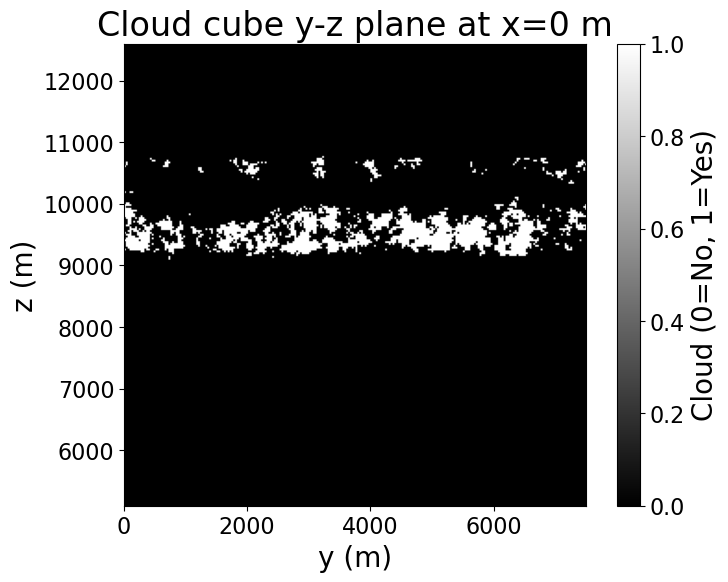

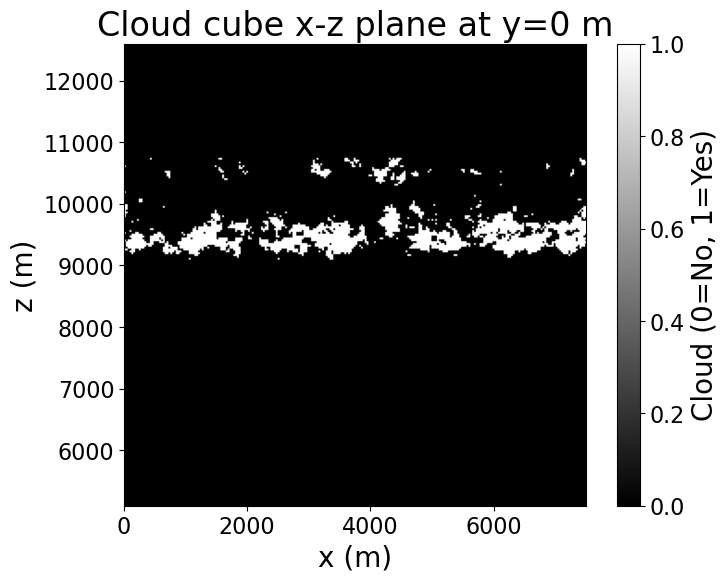

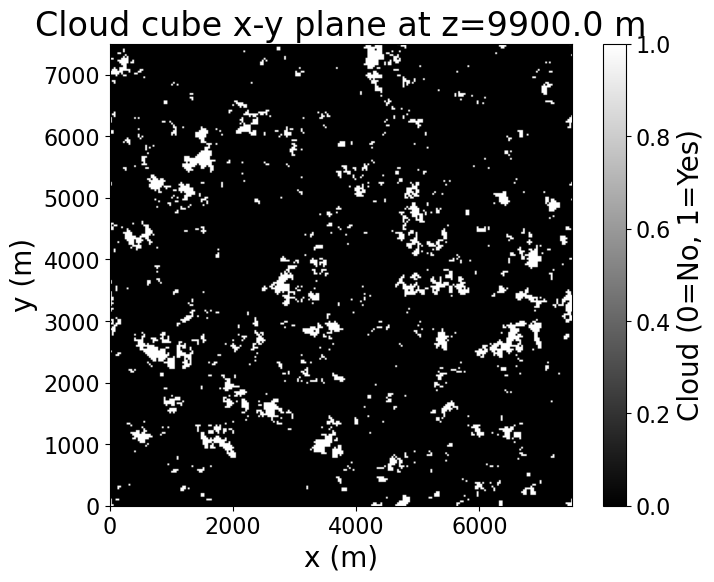

In [12]:
import matplotlib.pyplot as plt
site_altitude = altitude_ground
# ==========================================
# 1. Y-Z Plane (at x = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    cloud_cube[0, :, :].T,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='gray', origin='lower', 
    vmin=0, vmax=1
)
plt.colorbar(label="Cloud (0=No, 1=Yes)")
plt.title(f"Cloud cube y-z plane at x=0 m")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 2. X-Z Plane (at y = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    cloud_cube[:, 0, :].T,
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='gray', origin='lower', 
    vmin=0, vmax=1
)
plt.colorbar(label="Cloud (0=No, 1=Yes)")
plt.title(f"Cloud cube x-z plane at y=0 m")
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.show()

# ==========================================
# 3. X-Y Plane (at z = site_altitude)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    cloud_cube[:, :, 160].T,
    extent=(0, Lbox, 0, Lbox),
    cmap='gray', origin='lower',
    vmin=0, vmax=1
)
plt.colorbar(label="Cloud (0=No, 1=Yes)")
plt.title(f"Cloud cube x-y plane at z={z[160]} m")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()

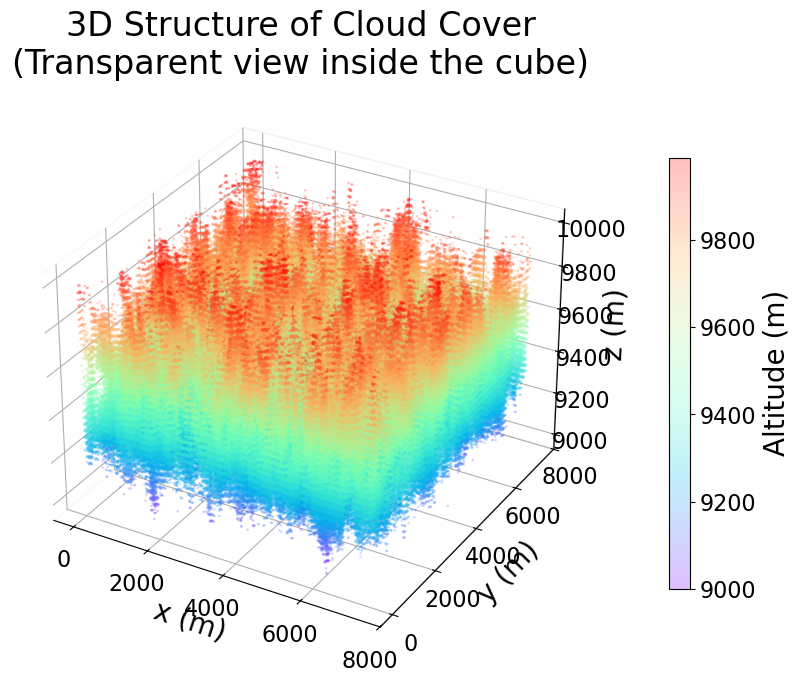

In [18]:
#Let's plot the cube

# 3. Create spatial coordinates and scale them to your physical Box Length (L)
x, y, z = np.indices(cloud_cube.shape)
spacing = Lbox / cloud_cube.shape[0]
x = x * spacing
y = y * spacing
z = z * spacing + site_altitude  # Shift z to start at the site altitude instead of 0

# 4. Create a mask to only plot the clouds
# Since cloud_cube is binary (1 for cloud, 0 for empty sky), we just select the 1s! and we stop at 10000 m on z
mask = (cloud_cube == 1) & (z <= 10000) & (z >= 9000)

# 5. Set up the 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 6. Plot the 3D scatter points
# APPLY THE MASK to x, y, and z so it skips the empty sky!
# Trick: Use c=z[mask] to color the clouds based on their altitude for a cool 3D effect
sc = ax.scatter(x[mask], y[mask], z[mask], 
                c=z[mask],             # <--- Coloring by height makes it look 3D
                cmap='rainbow', 
                alpha=0.25,            # <--- Lowered alpha slightly for better see-through fog
                s=3,                   # <--- Shrunk dot size to look more like mist
                linewidth=0)

# 7. Add labels and formatting
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label("Altitude (m)")         # Updated label since we color by Z

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
ax.set_title(f"3D Structure of Cloud Cover\n(Transparent view inside the cube)")

# Set the background to white/grey to make the colors pop
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.show()

In [13]:
def specific_humidity_to_vapor_pressure(q: float, p: float, t: float = None) -> float:
    """
    Converts specific humidity to water vapor pressure.
    
    Parameters:
    -----------
    q : array_like
        Specific humidity in kg/kg.
    p : array_like
        Total atmospheric pressure in hPa (or mb).
        
    Returns:
    --------
    array_like
        Water vapor pressure (e) in the same units as 'p' (hPa).
    """
    # Ratio of the molecular weight of water vapor to dry air
    EPSILON = 0.622 
    
    # Calculate water vapor pressure
    e = (q * p) / (EPSILON + q * (1.0 - EPSILON))
    
    return e

In [14]:
p_water_total_3d_grid = specific_humidity_to_vapor_pressure(q_total_3d_grid, p_3d_grid)

p_water_mean_3d_grid = specific_humidity_to_vapor_pressure(q_3d_grid, p_3d_grid)

Let's try generating a cloud from ERA5

In [1]:
#first, we import a profile
from scipy import constants
import xarray as xr
import pandas as pd
dataset = xr.open_dataset("/pscratch/sd/v/valer/icetmosphere/era5_profiles/dataset_2024-09_19-21-23.nc")

# SO site location
target_lon = -67.78
target_lat = -22.95

data_sep23 = dataset.interp(longitude=target_lon, latitude=target_lat, method="linear")
data_sep23 = data_sep23.sel(valid_time="2024-09-23T07:00:00")

site_altitude = 5100  # altitude of the site in meters
# Compute altitude from geopotential (z / g)
g = constants.g  # acceleration due to gravity from scipy.constants
altitude23 = data_sep23['z'].values / g  # altitude in meters for Sep 23

wvmr23 = data_sep23['q'].values #kg/kg
t23 = data_sep23['t'].values #K
cc23 = data_sep23['cc'].values #cloud cover ratio
ciwc23 = data_sep23['ciwc'].values #kg/kg
rh23 = data_sep23['r'].values #relative humidity in %
p23 = data_sep23['pressure_level'].values #hPa

# Ratio of the molecular weight of water vapor to dry air
epsilon = 0.62198

# Calculate vapor pressure
p_w23 = (wvmr23 * p23) / (epsilon + wvmr23)  # Vapor pressure in hPa

In [15]:
import numpy as np
from scipy.ndimage import gaussian_filter1d, uniform_filter1d

# --- 1. Your Interpolation Setup ---
dz = 10 # vertical resolution in meters
L_era5 = altitude23[-1] - altitude23[0]
N_grid_era5 = int(L_era5 / dz)

altitude = np.linspace(altitude23.min(), altitude23.max(), N_grid_era5)

wvmr = np.interp(altitude, altitude23, wvmr23)
t    = np.interp(altitude, altitude23, t23)
cc   = np.interp(altitude, altitude23, cc23)
ciwc = np.interp(altitude, altitude23, ciwc23)
rh   = np.interp(altitude, altitude23, rh23)
p    = np.interp(altitude, altitude23, p23)

# --- 2. Defining the Free Parameter ---
# You can change this value to whatever you want (in meters)
injection_scale = 500 # meters 

# --- 3. Grid Conversions ---
# Convert physical meters to array indices based on your dz
# Uniform filter requires an integer window size
window_size = int(np.round(injection_scale / dz)) 
sigma = window_size / np.sqrt(12)  # Convert window size to sigma for Gaussian filter


wvmr_gaussian = gaussian_filter1d(wvmr, sigma=sigma)
wvmr_uniform = uniform_filter1d(wvmr, size=window_size)


ciwc_uniform = uniform_filter1d(ciwc, size=window_size)


cc_uniform = np.clip(uniform_filter1d(cc, size=window_size), 0.0, 1.0)


#for temperature

t_uniform = uniform_filter1d(t, size=window_size)

p_uniform = uniform_filter1d(p, size=window_size)

rh_uniform = np.clip(uniform_filter1d(rh, size=window_size))

In [50]:
#for the 3D cube
import jax 
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
import numpy as np
import atmo3 as a3 
pi = np.pi

# --- Example Usage ---
L0 = 500.0   # Injection scale m
dz = 40.0     #  meter resolution
N_grid = 256
Lbox = N_grid * dz  # size of the box in m

print("maximum height of the cube =",Lbox+ site_altitude, "m")


#UTC_hour = 15
altitude_ground = 5100
beta = -11/3
seed = 123456789

# Initialize atmosphere
atmo = a3.Atmosphere(nside_grid=N_grid, box_length_in_m=Lbox, site_altitude=altitude_ground)

# Define wavenumbers and power spectrum
dk = atmo.grid_wsp.dk
k = np.arange(N_grid) * dk
k0 = 2 * np.pi / L0
k_tot = np.sqrt(k0**2 + k**2)
pofk = k_tot**beta
pofk/= np.max(pofk)
pspec = {'k': k, 'pofk': pofk}




rescale = {'h': altitude, 'f': wvmr_uniform/25} # we divide by 15 to get smaller variations for the cube, but still assume that variations are proportional to the wvmr profile



# Add component to atmosphere
field_name_v = 'wvmr variations'
field_unit_v = 'in kg/kg'

atmo.add_component(
    field_name=field_name_v,
    field_unit=field_unit_v,
    pspec=pspec,
    rescale=rescale,
    seed=seed,
    #mean=mean_q
)


atmo.generate_realization(time_step=0, component_name=field_name_v)

# Extract your final 3D JAX arrays
q_variations_cube = atmo.components[field_name_v].field


maximum height of the cube = 15340.0 m


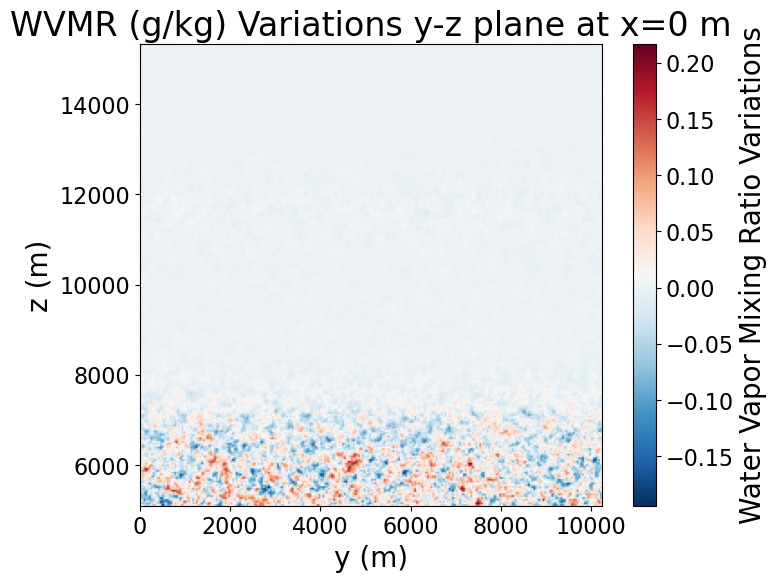

In [51]:
#Let's plot a slice xz at multiple y to see wvmr variations in the cube

import matplotlib.pyplot as plt
site_altitude = altitude_ground
# ==========================================
# 1. Y-Z Plane (at x = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    q_variations_cube[0, :, :].T*1e3,  # Convert to g/kg for better visibility
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='RdBu_r', origin='lower',#vmax=0.15, vmin=-0.15 
)
plt.colorbar(label="Water Vapor Mixing Ratio Variations")
plt.title(f"WVMR (g/kg) Variations y-z plane at x=0 m")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()



In [ ]:
# 3. Add the property using the exact dictionary structure atmo3 expects
atmo.add_property(
    property_name='temperature',
    property_unit='K',
    property_value={
        'h': altitude,
        'f': t_uniform
    }
)

# Project the 1D property into a 3D JAX array
temperature_3d_grid = atmo.grid_wsp.interp2grid(
    atmo.properties['temperature']['value']['h'], 
    atmo.properties['temperature']['value']['f']
)

# 3. Add the property using the exact dictionary structure atmo3 expects
atmo.add_property(
    property_name='specific humidity',
    property_unit='kg/kg',
    property_value={
        'h': altitude,
        'f': wvmr_uniform
    }
)

# Project the 1D property into a 3D JAX array
q_3d_grid = atmo.grid_wsp.interp2grid(
    atmo.properties['specific humidity']['value']['h'], 
    atmo.properties['specific humidity']['value']['f']
)

# 3. Add the property using the exact dictionary structure atmo3 expects
atmo.add_property(
    property_name='pressure',
    property_unit='hPa',
    property_value={
        'h': altitude,
        'f': p_uniform
    }
)

# Project the 1D property into a 3D JAX array
p_3d_grid = atmo.grid_wsp.interp2grid(
    atmo.properties['pressure']['value']['h'], 
    atmo.properties['pressure']['value']['f']
)



In [52]:
rh_mean_3d_grid = calculate_relative_humidity(p_3d_grid, temperature_3d_grid, q_3d_grid)

rh_fluctuations_3d_grid = calculate_relative_humidity(p_3d_grid, temperature_3d_grid, q_variations_cube)

rh_total_3d_grid = calculate_relative_humidity(p_3d_grid, temperature_3d_grid, q_3d_grid + q_variations_cube)

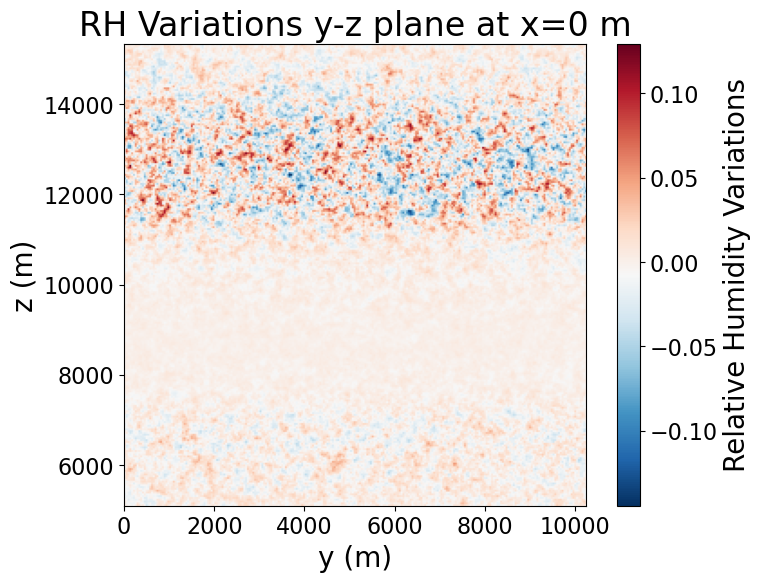

In [53]:
#let's plot rh fluctuations in the cube

#Let's plot a slice xz at multiple y to see rh variations in the cube

import matplotlib.pyplot as plt
site_altitude = altitude_ground
# ==========================================
# 1. Y-Z Plane (at x = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    rh_fluctuations_3d_grid[0, :, :].T,  # Convert to g/kg for better visibility
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='RdBu_r', origin='lower',#vmax=0.2, vmin=-0.2 
)
plt.colorbar(label="Relative Humidity Variations")
plt.title(f"RH Variations y-z plane at x=0 m")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

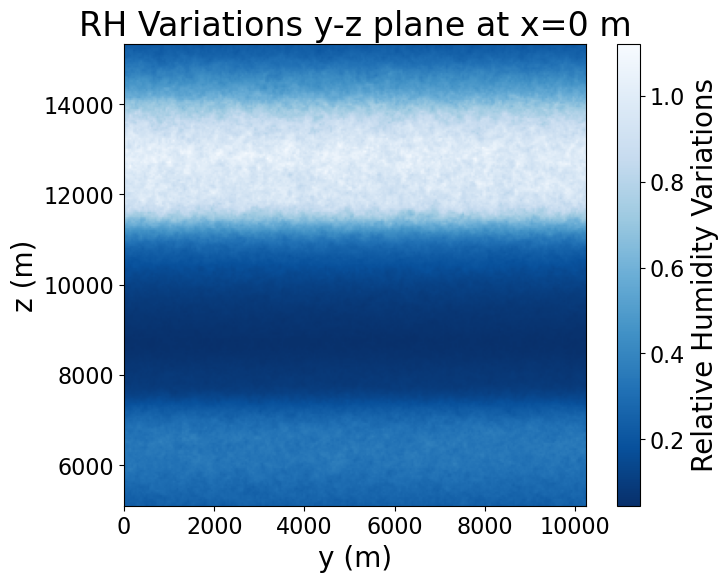

In [58]:


#Let's plot a slice xz at multiple y to see full rh  in the cube

import matplotlib.pyplot as plt
site_altitude = altitude_ground
# ==========================================
# 1. Y-Z Plane (at x = 0)
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(
    rh_total_3d_grid[0, :, :].T,  # Convert to g/kg for better visibility
    extent=(0, Lbox, site_altitude, site_altitude + Lbox),
    cmap='Blues_r', origin='lower',#vmax=0.2, vmin=-0.2 
)
plt.colorbar(label="Relative Humidity Variations")
plt.title(f"RH Variations y-z plane at x=0 m")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

In [55]:
import jax.numpy as jnp

# ==========================================
# Generate JAX Cloud Cube (Threshold RH > 1)
# ==========================================

# 1. (rh_tot > 1.0) creates a 3D boolean cube of True/False
# 2. .astype(jnp.int32) instantly converts True to 1 and False to 0
cloud_cube = (rh_total_3d_grid > 1.0).astype(jnp.int32)

In [56]:
#Let's calculcate cc_ratio_atmo3 the cloud cover ratio as a function of z in the cube and compare it to the cc_ratio profile we wanted to impose at the beginning (which is a function of z only)

cc_ratio_atmo3 = jnp.mean(cloud_cube, axis=(0,1))

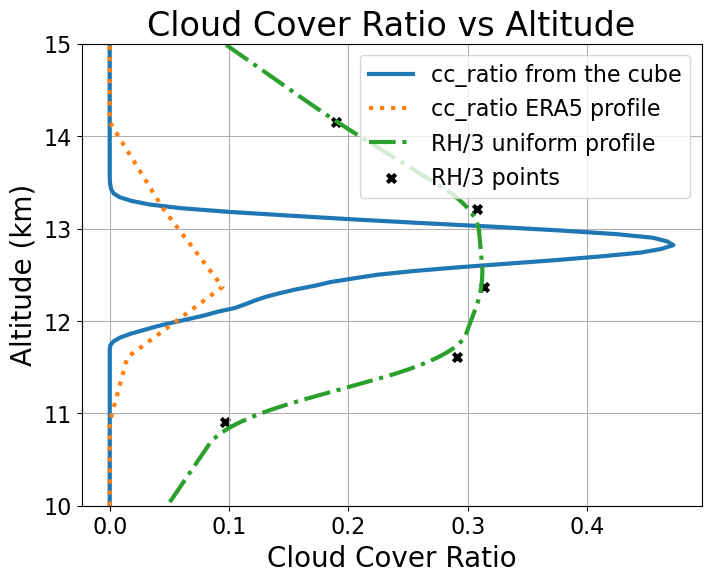

In [64]:
altitude_atmo3 = altitude_ground + np.arange(N_grid) * dz

plt.figure(figsize=(8, 6))
plt.plot(cc_ratio_atmo3, altitude_atmo3/1e3, label='cc_ratio from the cube')
#plt.plot(cc_uniform, altitude/1e3, label='cc_ratio uniform profile', linestyle='dashed')
plt.plot(cc23, altitude23/1e3, label='cc_ratio ERA5 profile', linestyle='dotted')
plt.plot(rh_uniform/300, altitude/1e3, label='RH/3 uniform profile', linestyle='dashdot')
plt.scatter(rh23/300, altitude23/1e3, label='RH/3 points', color='black', marker='x')
plt.xlabel('Cloud Cover Ratio')
plt.ylabel('Altitude (km)')
plt.title('Cloud Cover Ratio vs Altitude')
plt.ylim(10,15)
plt.legend(loc='upper right')
plt.grid()
plt.show()